## データの前処理

In [40]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 回転とリサイズ
affine = transforms.RandomAffine([-30, 30], scale=(0.8, 1.2))
# シフト
shift = transforms.RandomAffine((0, 0), translate=(0.5, 0.5))
# 左右反転
flip = transforms.RandomHorizontalFlip(p=0.5)
# 一部を消去
erasing = transforms.RandomErasing(p=0.5)
# 平均値を0, 標準偏差を1にする
normalize = transforms.Normalize((0.0, 0.0, 0.0), (1.0, 1.0, 1.0))
to_tensor = transforms.ToTensor()

# ノイズなしの訓練データ
transform_train = transforms.Compose([to_tensor, normalize])
# 一部消去した訓練データ
transform_train_erasing = transforms.Compose([to_tensor, erasing, normalize])

transform_test = transforms.Compose([to_tensor, normalize])
cifar10_train = CIFAR10("./data", train=True, download=True, transform=transform_train)
cifar10_train_erasing = CIFAR10("./data", train=True, download=True, transform=transform_train_erasing)
cifar10_test = CIFAR10("./data", train=False, download=True, transform=transform_test)

# DataLoaderの設定
batch_size = 64
train_loader = DataLoader(cifar10_train, batch_size=batch_size, shuffle=True)
train_loader_erasing = DataLoader(cifar10_train_erasing, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(cifar10_test, batch_size=batch_size, shuffle=False)

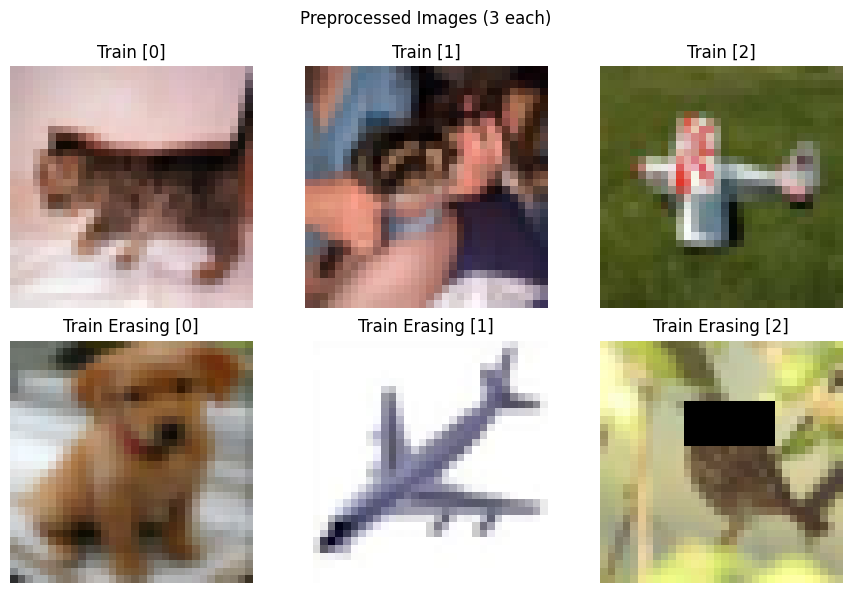

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(9, 6))

for i in range(3):
    img = next(iter(train_loader))[0][i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    axes[0][i].imshow(img)
    axes[0][i].set_title(f"Train [{i}]")
    axes[0][i].axis('off')

for i in range(3):
    img = next(iter(train_loader_erasing))[0][i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    axes[1][i].imshow(img)
    axes[1][i].set_title(f"Train Erasing [{i}]")
    axes[1][i].axis('off')

    axes[0][0].set_ylabel("Train", fontsize=12)
    axes[1][0].set_ylabel("Train Erasing", fontsize=12)
plt.suptitle("Preprocessed Images (3 each)")
plt.tight_layout()
plt.show()

In [42]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # 畳み込み層（入力チャンネル数、フィルタ数、フィルタサイズ）
        self.conv1 = nn.Conv2d(3, 6, 5)
        # 活性化関数ReLU
        self.relu = nn.ReLU()
        # プーリング層（領域のサイズ、領域の感覚）
        self.pool = nn.MaxPool2d(2, 2)
        # 畳み込み層
        self.conv2 = nn.Conv2d(6, 16, 5)
        # 全結合層
        self.fc1 = nn.Linear(16*5*5, 256)
        # ドロップアウト（ドロップアウト率）
        self.dropout = nn.Dropout(p=0.5)
        # 全結合層
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 16*5*5)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x
    
net = Net()
net.cuda() # GPU対応
print(net)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


### ノイズなしのデータセットで学習

In [43]:
from torch import optim

# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
x_test, t_test = next(iter(test_loader))
x_test, t_test = x_test.cuda(), t_test.cuda()
for i in range(20): # 20エポック学習
    net.train() # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader): # ミニバッチ（x, t)を取り出す
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()    # パラメータの更新
    loss_train /= j+1   # 平均値をとる
    record_loss_train.append(loss_train)

    # 評価モード
    net.eval()
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)
        

Epoch: 0 Loss_Train: 1.784343764910003 Loss_Test: 1.5263145266065172
Epoch: 1 Loss_Train: 1.5184069306344328 Loss_Test: 1.4241163890073254
Epoch: 2 Loss_Train: 1.4281470267973897 Loss_Test: 1.3546194863167538
Epoch: 3 Loss_Train: 1.3602885809700813 Loss_Test: 1.2773126602932146
Epoch: 4 Loss_Train: 1.3121495961075853 Loss_Test: 1.247250075173226
Epoch: 5 Loss_Train: 1.2734075580411555 Loss_Test: 1.2230840105160026
Epoch: 6 Loss_Train: 1.2470001779553834 Loss_Test: 1.1900402163244357
Epoch: 7 Loss_Train: 1.2207768884156367 Loss_Test: 1.1896883055662653
Epoch: 8 Loss_Train: 1.2043398675101493 Loss_Test: 1.2762776647403742
Epoch: 9 Loss_Train: 1.1788634064862185 Loss_Test: 1.1308694667876906
Epoch: 10 Loss_Train: 1.1577105830849894 Loss_Test: 1.1589848919279258
Epoch: 11 Loss_Train: 1.147499887992049 Loss_Test: 1.1227747410725637
Epoch: 12 Loss_Train: 1.1260932235766554 Loss_Test: 1.1105671270637756
Epoch: 13 Loss_Train: 1.1144201472744613 Loss_Test: 1.1241650319403145
Epoch: 14 Loss_Trai

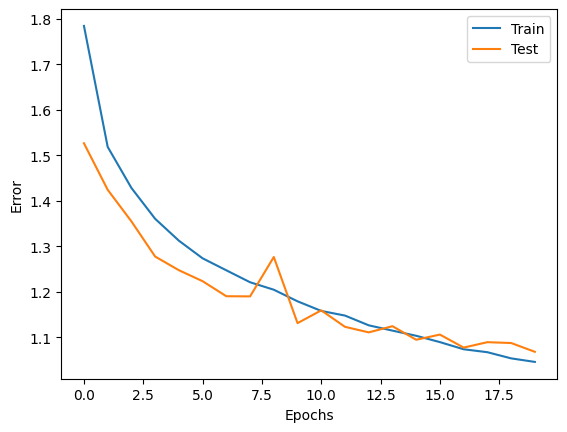

In [44]:
import matplotlib.pyplot as plt

plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.plot(range(len(record_loss_test)), record_loss_test, label="Test")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

In [45]:
correct = 0
total = 0
net.eval()
for j, (x, t) in enumerate(test_loader):
    x, t = x.cuda(), t.cuda()
    y = net(x)
    correct += (y.argmax(1) == t).sum().item()
    total += len(x)
print("正解率: ", str(correct/total*100) + "%")

正解率:  61.970000000000006%


### 一部消去したデータセットで学習

In [46]:
# netを初期化
net = Net()
net.cuda()

from torch import optim

# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train_erasing = []
record_loss_test_erasing = []

# 学習
x_test, t_test = next(iter(test_loader))
x_test, t_test = x_test.cuda(), t_test.cuda()
for i in range(20): # 20エポック学習
    net.train() # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader_erasing): # ミニバッチ（x, t)を取り出す
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()    # パラメータの更新
    loss_train /= j+1   # 平均値をとる
    record_loss_train_erasing.append(loss_train)

    # 評価モード
    net.eval()
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test_erasing.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)
        

Epoch: 0 Loss_Train: 1.8642402728805152 Loss_Test: 1.5506108832207455
Epoch: 1 Loss_Train: 1.6224188763467247 Loss_Test: 1.4428604575479107
Epoch: 2 Loss_Train: 1.5512828895502992 Loss_Test: 1.364193025667956
Epoch: 3 Loss_Train: 1.5007294509416955 Loss_Test: 1.3162895942189892
Epoch: 4 Loss_Train: 1.465693049723535 Loss_Test: 1.3070617967350469
Epoch: 5 Loss_Train: 1.435827858765107 Loss_Test: 1.2978319089124157
Epoch: 6 Loss_Train: 1.4085642953053155 Loss_Test: 1.2426961580659175
Epoch: 7 Loss_Train: 1.3888858600955485 Loss_Test: 1.2497147074930228
Epoch: 8 Loss_Train: 1.367418956192558 Loss_Test: 1.2251017230331518
Epoch: 9 Loss_Train: 1.3549715382668672 Loss_Test: 1.1869287054250195
Epoch: 10 Loss_Train: 1.3420523046837438 Loss_Test: 1.1797119853602853
Epoch: 11 Loss_Train: 1.3305124775375552 Loss_Test: 1.183497803985693
Epoch: 12 Loss_Train: 1.31853148943323 Loss_Test: 1.1672453622149814
Epoch: 13 Loss_Train: 1.3053595865016703 Loss_Test: 1.1518437892768034
Epoch: 14 Loss_Train: 1

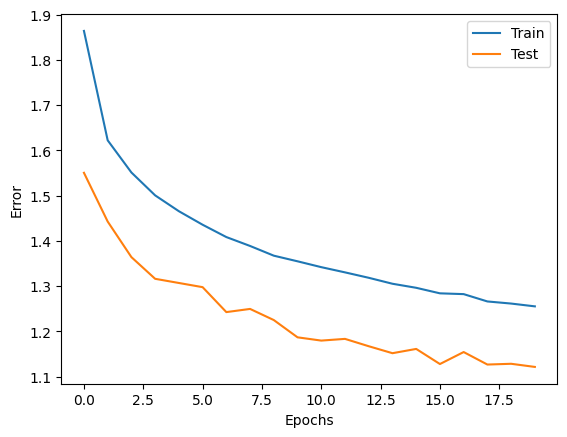

In [47]:
import matplotlib.pyplot as plt

plt.plot(range(len(record_loss_train_erasing)), record_loss_train_erasing, label="Train")
plt.plot(range(len(record_loss_test_erasing)), record_loss_test_erasing, label="Test")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

In [48]:
correct = 0
total = 0
net.eval()
for j, (x, t) in enumerate(test_loader):
    x, t = x.cuda(), t.cuda()
    y = net(x)
    correct += (y.argmax(1) == t).sum().item()
    total += len(x)
print("正解率: ", str(correct/total*100) + "%")

正解率:  60.69%


### モデルの検討①
- フィルタサイズを小さくする
- チャンネル数を増やす
- 一部塗りつぶしデータで実行  
**→10%以上の向上に成功**

In [ ]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # 畳み込み層（入力チャンネル数、フィルタ数、フィルタサイズ）
        self.conv1 = nn.Conv2d(3, 32, 3)     # フィルタ数6->32、フィルタサイズ5->3
        self.conv2 = nn.Conv2d(32, 64, 3)        # フィルタ数16->64、フィルタサイズを5->3

        # 活性化関数ReLU
        self.relu = nn.ReLU()

        # プーリング層（領域のサイズ、領域の感覚）
        self.pool = nn.MaxPool2d(2, 2)
        
        # 全結合層
        self.fc1 = nn.Linear(64*6*6, 256)

        # ドロップアウト（ドロップアウト率）
        self.dropout = nn.Dropout(p=0.5)

        # 全結合層
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)
        
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

net = Net()
net.cuda() # GPU対応
print(net)

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=2304, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [52]:
# netを初期化
net = Net()
net.cuda()

from torch import optim

# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train_erasing = []
record_loss_test_erasing = []

# 学習
x_test, t_test = next(iter(test_loader))
x_test, t_test = x_test.cuda(), t_test.cuda()
for i in range(20): # 20エポック学習
    net.train() # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader_erasing): # ミニバッチ（x, t)を取り出す
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()    # パラメータの更新
    loss_train /= j+1   # 平均値をとる
    record_loss_train_erasing.append(loss_train)

    # 評価モード
    net.eval()
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test_erasing.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)
        

Epoch: 0 Loss_Train: 1.749662307522181 Loss_Test: 1.4307521156444671
Epoch: 1 Loss_Train: 1.4626011187615602 Loss_Test: 1.2593033207449944
Epoch: 2 Loss_Train: 1.3476401056779925 Loss_Test: 1.1436873830048142
Epoch: 3 Loss_Train: 1.2676638742846906 Loss_Test: 1.089983224489127
Epoch: 4 Loss_Train: 1.2166416794442765 Loss_Test: 1.0617218670571686
Epoch: 5 Loss_Train: 1.1692295100377954 Loss_Test: 1.0349192695253213
Epoch: 6 Loss_Train: 1.131622781915128 Loss_Test: 0.985497449234033
Epoch: 7 Loss_Train: 1.1027341515511808 Loss_Test: 0.9944298768499095
Epoch: 8 Loss_Train: 1.0761796485280137 Loss_Test: 0.9566123432414547
Epoch: 9 Loss_Train: 1.047365158262765 Loss_Test: 0.9124145879866971
Epoch: 10 Loss_Train: 1.0278609731922979 Loss_Test: 0.8986187197600201
Epoch: 11 Loss_Train: 1.0148942780006878 Loss_Test: 0.889228866738119
Epoch: 12 Loss_Train: 0.9936778969929346 Loss_Test: 0.8770405095853623
Epoch: 13 Loss_Train: 0.9766761226879667 Loss_Test: 0.8742399033467481
Epoch: 14 Loss_Train: 

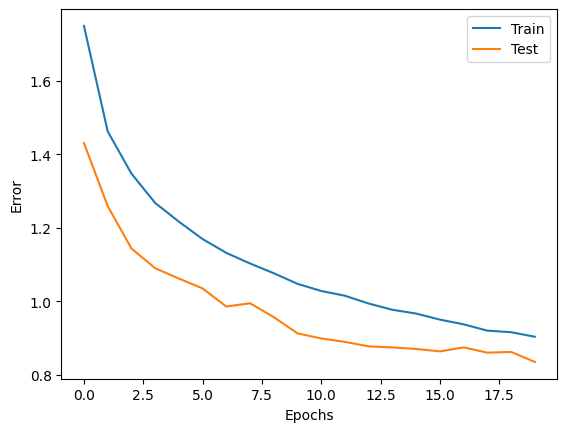

In [53]:
import matplotlib.pyplot as plt

plt.plot(range(len(record_loss_train_erasing)), record_loss_train_erasing, label="Train")
plt.plot(range(len(record_loss_test_erasing)), record_loss_test_erasing, label="Test")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

In [54]:
correct = 0
total = 0
net.eval()
for j, (x, t) in enumerate(test_loader):
    x, t = x.cuda(), t.cuda()
    y = net(x)
    correct += (y.argmax(1) == t).sum().item()
    total += len(x)
print("正解率: ", str(correct/total*100) + "%")

正解率:  71.21%


## モデルの検討➁
- 畳み込み→ReLU→プーリングの回数を増やす
- 一部塗りつぶしデータで実行  
**→あまり精度変わらず**

In [55]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # 畳み込み層（入力チャンネル数、フィルタ数、フィルタサイズ）
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.conv3 = nn.Conv2d(64, 128, 3)      # 追加

        # 活性化関数ReLU
        self.relu = nn.ReLU()

        # プーリング層（領域のサイズ、領域の感覚）
        self.pool = nn.MaxPool2d(2, 2)

        # 全結合層
        self.fc1 = nn.Linear(128 * 2 * 2, 256)

        # ドロップアウト（ドロップアウト率）
        self.dropout = nn.Dropout(p=0.5)

        # 全結合層
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)

        # 追加
        x = self.relu(self.conv3(x))
        x = self.pool(x)

        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

net = Net()
net.cuda() # GPU対応
print(net)

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=512, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [56]:
# netを初期化
net = Net()
net.cuda()

from torch import optim

# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# 最適化アルゴリズム
optimizer = optim.Adam(net.parameters())

# 損失のログ
record_loss_train_erasing = []
record_loss_test_erasing = []

# 学習
x_test, t_test = next(iter(test_loader))
x_test, t_test = x_test.cuda(), t_test.cuda()
for i in range(20): # 20エポック学習
    net.train() # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader_erasing): # ミニバッチ（x, t)を取り出す
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()    # パラメータの更新
    loss_train /= j+1   # 平均値をとる
    record_loss_train_erasing.append(loss_train)

    # 評価モード
    net.eval()
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):
        x, t = x.cuda(), t.cuda()
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test_erasing.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)
        

Epoch: 0 Loss_Train: 1.8617994093224215 Loss_Test: 1.574787210506998
Epoch: 1 Loss_Train: 1.5586027753017748 Loss_Test: 1.3318172640101924
Epoch: 2 Loss_Train: 1.4077374095197224 Loss_Test: 1.2339477167008028
Epoch: 3 Loss_Train: 1.3078719213643037 Loss_Test: 1.1713875706788082
Epoch: 4 Loss_Train: 1.232162363084076 Loss_Test: 1.0642318186486603
Epoch: 5 Loss_Train: 1.1663286097519232 Loss_Test: 1.073755456763468
Epoch: 6 Loss_Train: 1.1087248287999723 Loss_Test: 0.9462900340177451
Epoch: 7 Loss_Train: 1.0718330307232449 Loss_Test: 0.9429720461748208
Epoch: 8 Loss_Train: 1.0372966871694531 Loss_Test: 0.8983199543254391
Epoch: 9 Loss_Train: 1.0076377708131394 Loss_Test: 0.8835457916472368
Epoch: 10 Loss_Train: 0.979969025725294 Loss_Test: 0.858556023069248
Epoch: 11 Loss_Train: 0.9568975292660696 Loss_Test: 0.8842384481126335
Epoch: 12 Loss_Train: 0.9347067908252902 Loss_Test: 0.8809092044830322
Epoch: 13 Loss_Train: 0.9134248621628412 Loss_Test: 0.8323034048080444
Epoch: 14 Loss_Train:

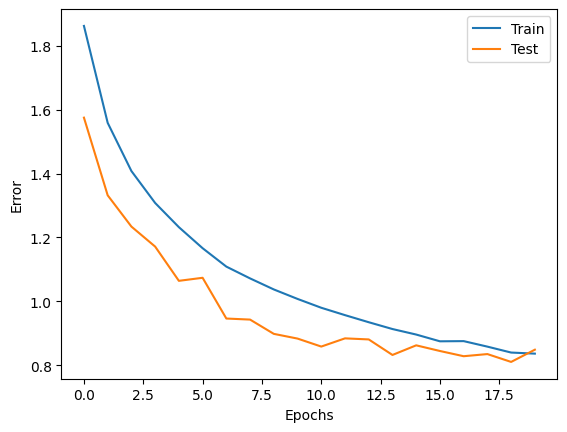

In [57]:
import matplotlib.pyplot as plt

plt.plot(range(len(record_loss_train_erasing)), record_loss_train_erasing, label="Train")
plt.plot(range(len(record_loss_test_erasing)), record_loss_test_erasing, label="Test")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

In [58]:
correct = 0
total = 0
net.eval()
for j, (x, t) in enumerate(test_loader):
    x, t = x.cuda(), t.cuda()
    y = net(x)
    correct += (y.argmax(1) == t).sum().item()
    total += len(x)
print("正解率: ", str(correct/total*100) + "%")

正解率:  70.91%
